# System-Level Prediction — Step-by-Step Walkthrough

Pipeline for `bpic_12_A.xes`:
1. Dataset statistics & EDA
2. Data processing → KPI time series
3. Forecasting
4. Evaluation

## 0. Setup

In [1]:
from pathlib import Path
import sys

# Add project root to path
ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT))

DATA    = ROOT / "data" / "bpic_12_A.xes"
CACHE   = ROOT / "cache"
RESULTS = ROOT / "results"

CACHE.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

print("Data file exists:", DATA.exists())

Data file exists: True


## 1. Dataset Statistics & EDA

In [2]:

import pm4py

df_raw = pm4py.read_xes(str(DATA))
print(f"Events: {len(df_raw):,}")
print(f"Cases:  {df_raw['case:concept:name'].nunique():,}")
print(f"Period: {df_raw['time:timestamp'].min()} → {df_raw['time:timestamp'].max()}")
df_raw.head()

/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/pm4py/util/dt_parsing/parser.py:82: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(
/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 13087/13087 [00:01<00:00, 9135.10it/s]


Events: 60,849
Cases:  13,087
Period: 2011-09-30 22:38:44.546000+00:00 → 2012-03-14 14:33:57.651000+00:00


,Unnamed: 0,org:resource,lifecycle:transition,concept:name,time:timestamp,case:REG_DATE,case:concept:name,case:AMOUNT_REQ
0,0,112,COMPLETE,A_SUBMITTED,2011-09-30 22:38:44.546000+00:00,2011-10-01 00:38:44.546000+02:00,173688,20000
1,1,112,COMPLETE,A_PARTLYSUBMITTED,2011-09-30 22:38:44.880000+00:00,2011-10-01 00:38:44.546000+02:00,173688,20000
2,2,112,COMPLETE,A_PREACCEPTED,2011-09-30 22:39:37.906000+00:00,2011-10-01 00:38:44.546000+02:00,173688,20000
3,3,10862,COMPLETE,A_ACCEPTED,2011-10-01 09:42:43.308000+00:00,2011-10-01 00:38:44.546000+02:00,173688,20000
4,4,10862,COMPLETE,A_FINALIZED,2011-10-01 09:45:09.243000+00:00,2011-10-01 00:38:44.546000+02:00,173688,20000


## 2. Data Processing — Build KPI Time Series

In [4]:
from old_master_thesis.data_processing import Config, import_data, build_concurrent_cases_series, build_resource_utilization_series, build_throughput_time_series
import matplotlib.pyplot as plt

cfg = Config(
    dataset=DATA,
    cache_dir=CACHE,
)

df = import_data(cfg, load=True)
print(f"Loaded {len(df):,} events")

parsing log, completed traces :: 100%|██████████| 13087/13087 [00:01<00:00, 8973.05it/s]


Loaded 60,849 events


### 2a. Concurrent Cases

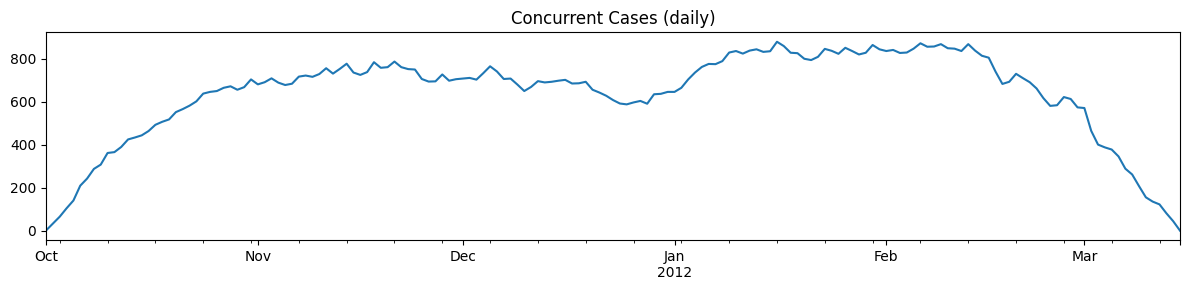

count    167.000000
mean     638.694611
std      209.439663
min        0.000000
25%      590.500000
50%      694.000000
75%      779.500000
max      878.000000
Name: concurrent_cases, dtype: float64


In [5]:
ts_cc = build_concurrent_cases_series(cfg, df, load=True, variant="sweepline", freq="1D", smoothing=True)
ts_cc.plot(title="Concurrent Cases (daily)", figsize=(12, 3))
plt.tight_layout()
plt.show()
print(ts_cc.describe())

### 2b. Resource Utilization

In [ ]:
ts_ru = build_resource_utilization_series(cfg, df, load=True, freq="1D")
ts_ru.plot(title="Resource Utilization (daily)", figsize=(12, 3))
plt.tight_layout()
plt.show()
print(ts_ru.describe())

### 2c. Throughput Time

In [ ]:
ts_tt = build_throughput_time_series(cfg, df, load=True, variant="span", freq="1D", smoothing=True)
ts_tt.plot(title="Throughput Time (daily)", figsize=(12, 3))
plt.tight_layout()
plt.show()
print(ts_tt.describe())

## 3. Forecasting

Runs hyperparameter tuning + forecasting for selected models and saves results to `results/`.

In [17]:
# Choose which KPI to forecast: "concurrent_cases", "resource_utilization", or "throughput_time"
SERIES = "concurrent_cases"

# Available models: "naive", "seasonal_naive", "ets", "sarimax", "ridge", "gru", "nbeats"
MODELS = ["naive", "ets", "sarimax"]

# Fraction of the series to use (required). 1.0 = full series, 0.75 = first 75%
TRUNCATION = 1.0

In [18]:
import subprocess, sys

cmd = [
    sys.executable, str(ROOT / "forecasting.py"),
    "-d", str(DATA),
    "-r", str(RESULTS),
    "-s", SERIES,
    "-tr", str(TRUNCATION),
    "-m", *MODELS,
]

print("Running:", " ".join(cmd))
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

Running: /Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/bin/python /Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/forecasting.py -d /Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/data/bpic_12_A.xes -r /Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/results -s concurrent_cases -tr 1.0 -m naive ets sarimax
TARGET: concurrent_cases - truncation: 1.0
Last train timestamp:  2012-01-24 00:00:00+00:00
Last validation timestamp:  2012-02-09 00:00:00+00:00
Last test timestamp:  2012-03-15 00:00:00+00:00

[TUNE] Model: model_naive (naive)  grid_size=1
  - candidate 1/1 params=None  val_MSE=298.062500
[RESULT] model_naive best_val_metric=298.062500  test_metric=189742.742857  best_params=None

[TUNE] Model: model_ets (ets)  grid_size=72
  - candidate 1/72 params={'trend': 'add', 'seasonal': 'add', 'error': 'add', 'seasonal_periods': 7, 'damped_trend': True}  val_MSE=76.328713
  - candidate 2/72 pa

## 4. Evaluation

In [19]:


pred_files = list(RESULTS.glob("*.csv"))
print(f"Found {len(pred_files)} prediction file(s):")
for f in pred_files:
    print(" ", f.name)

Found 0 prediction file(s):


In [20]:
# Update TEST_FILE to match the actual test CSV produced by forecasting.py
TEST_FILE = next((f for f in pred_files if "test" in f.name.lower()), pred_files[0] if pred_files else None)

if TEST_FILE:
    cmd_eval = [
        sys.executable, str(ROOT / "evaluation.py"),
        "-pred", str(RESULTS),
        "-test", str(TEST_FILE),
        "-file", TEST_FILE.name,
    ]
    print("Running:", " ".join(cmd_eval))
    result_eval = subprocess.run(cmd_eval, capture_output=True, text=True)
    print(result_eval.stdout)
    if result_eval.returncode != 0:
        print("STDERR:", result_eval.stderr)
else:
    print("No prediction files found — run Step 3 first.")

No prediction files found — run Step 3 first.
